In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Problem 01: **Duck-Chicken Classification** using transfer learning
### By: Ayushman Anupam (MDS202411)
This project focuses on classifying images of ducks and chickens using a transfer learning approach with a pre-trained Convolutional Neural Network (CNN). A ResNet18 model, pre-trained on the ImageNet dataset, was fine-tuned by replacing and training the **final 2 layers** while freezing earlier layers to retain learned features.

The dataset was organized into training, validation, and test sets, and appropriate image preprocessing and augmentation techniques were applied. The model was trained using the Adam optimizer and CrossEntropy loss. Performance was evaluated using accuracy and classification metrics, along with visualizations such as loss/accuracy curves and prediction analysis.

The results demonstrate that transfer learning enables effective image classification even with a relatively small dataset.


In [18]:
# importing needed libraries

import random, glob
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import datasets, transforms

from torch.utils.data import DataLoader


from sklearn.metrics import classification_report
from PIL import Image

# Paths
BASE_PATH = r"/content/drive/Othercomputers/My Laptop/AGDrive/Applied_Machine_Learning/Assignment 05"
paths = {
    "train_chicken": glob.glob(f"{BASE_PATH}/Problem01_DuckChicken_Dataset/train/chicken/*"),
    "train_duck": glob.glob(f"{BASE_PATH}/Problem01_DuckChicken_Dataset/train/duck/*"),
    "val_chicken": glob.glob(f"{BASE_PATH}/Problem01_DuckChicken_Dataset/validation/chicken/*"),
    "val_duck": glob.glob(f"{BASE_PATH}/Problem01_DuckChicken_Dataset/validation/duck/*"),
    "test_chicken": glob.glob(f"{BASE_PATH}/Problem01_DuckChicken_Dataset/test/chicken/*"),
    "test_duck": glob.glob(f"{BASE_PATH}/Problem01_DuckChicken_Dataset/test/duck/*"),
}


### Sample of Data

In [19]:
random.seed(9)
samples = {k: random.sample(v, min(10, len(v))) for k, v in paths.items()}

fig, ax = plt.subplots(6, 10, figsize=(18, 10))

row_titles = [
    "Train Dataset - Chicken",
    "Train Dataset - Duck",
    "Val Dataset - Chicken",
    "Val Dataset - Duck",
    "Test Dataset - Chicken",
    "Test Dataset - Duck"
]

keys = list(samples.keys())

for i, key in enumerate(keys):
    for j in range(10):
        if j < len(samples[key]):
            img = Image.open(samples[key][j])
            ax[i, j].imshow(img)
        ax[i, j].axis("off")

    ax[i, 0].set_title(row_titles[i], fontsize=12, loc='left')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#### Processing data

In [20]:
def paths_to_df(paths_dict, split):
    filepaths = []
    labels = []

    for key, files in paths_dict.items():
        if key.startswith(split):
            label = key.split('_')[1]   # chicken / duck
            filepaths.extend(files)
            labels.extend([label]*len(files))

    return pd.DataFrame({
        'filepath': filepaths,
        'class': labels
    })

train_data = paths_to_df(paths, "train")
validation_data = paths_to_df(paths, "val")
test_data = paths_to_df(paths, "test")

### Distribution of class in each dataset - train, validation and test

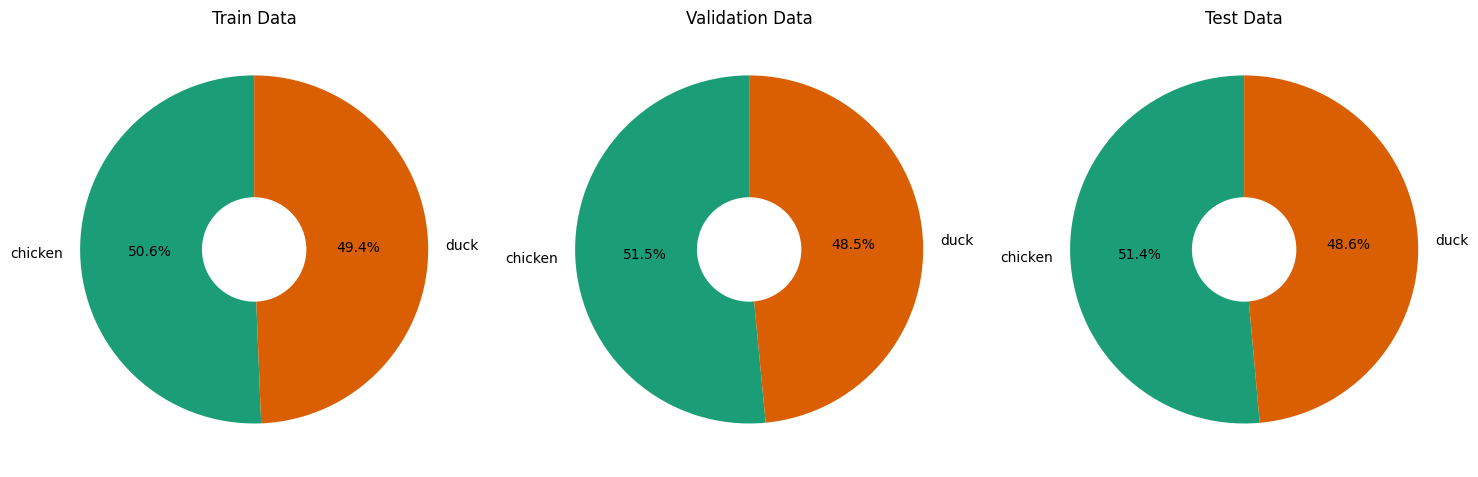

In [21]:
# get class distributions
train_counts = train_data.groupby('class').size()
val_counts = validation_data.groupby('class').size()
test_counts = test_data.groupby('class').size()

data_set = [train_counts, val_counts, test_counts]
titles = ['Train Data', 'Validation Data', 'Test Data']

# colors
colors = sns.color_palette('Dark2')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (data, ax) in enumerate(zip(data_set, axes)):
    wedges, texts, autotexts = ax.pie(
        data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )

    # create donut (white circle in center)
    centre_circle = plt.Circle((0, 0), 0.3, fc='white')
    ax.add_artist(centre_circle)

    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

### Processing Data for pytorch

In [22]:
# transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
}

# paths (USE YOUR BASE_PATH)
train_dir = f"{BASE_PATH}/Problem01_DuckChicken_Dataset/train"
val_dir = f"{BASE_PATH}/Problem01_DuckChicken_Dataset/validation"

# datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

# loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# class names
class_names = train_dataset.classes
print(class_names)

['chicken', 'duck']


In [23]:
# choosing device to train on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [24]:
# function to train model
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=5):
    train_acc_history, val_acc_history = [], []
    train_loss_history, val_loss_history = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        epoch_train_loss = 0
        epoch_val_loss = 0
        epoch_train_acc = 0
        epoch_val_acc = 0

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == 'train':
                epoch_train_loss = epoch_loss
                epoch_train_acc = epoch_acc.item()
            else:
                epoch_val_loss = epoch_loss
                epoch_val_acc = epoch_acc.item()

        train_loss_history.append(epoch_train_loss)
        val_loss_history.append(epoch_val_loss)
        train_acc_history.append(epoch_train_acc)
        val_acc_history.append(epoch_val_acc)

    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [25]:
# function to evaluate model
def evaluate_model(model, dataloader, device, class_names):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

### **Using ResNet 18 for transfer learning**


In [27]:

# load pretrained model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# freeze all layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze second-last block (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True

# replace final layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# (fc is automatically trainable since it's new)
model = model.to(device)

In [28]:
# adam as optimization function
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4   # lower LR for fine-tuning
)

In [29]:
# cross-entropy loss for classification
criterion = nn.CrossEntropyLoss()

# merging data for training
dataloaders = {
    'train': train_loader,
    'val': val_loader
}


### **Actual Training**

In [30]:
model, train_loss, val_loss, train_acc, val_acc = train_model(
    model, dataloaders, criterion, optimizer, device, num_epochs=7
)



Epoch 1/7
train Loss: 0.3131 | Acc: 0.8910
val Loss: 0.0778 | Acc: 0.9697

Epoch 2/7
train Loss: 0.0459 | Acc: 1.0000
val Loss: 0.0234 | Acc: 1.0000

Epoch 3/7
train Loss: 0.0256 | Acc: 0.9936
val Loss: 0.0288 | Acc: 0.9697

Epoch 4/7
train Loss: 0.0173 | Acc: 0.9936
val Loss: 0.0257 | Acc: 0.9697

Epoch 5/7
train Loss: 0.0056 | Acc: 1.0000
val Loss: 0.0160 | Acc: 1.0000

Epoch 6/7
train Loss: 0.0055 | Acc: 1.0000
val Loss: 0.0150 | Acc: 1.0000

Epoch 7/7
train Loss: 0.0030 | Acc: 1.0000
val Loss: 0.0182 | Acc: 1.0000


In [31]:
# evaluating model on train data
evaluate_model(model, dataloaders['train'], device, class_names)


Classification Report:

              precision    recall  f1-score   support

     chicken       1.00      1.00      1.00        79
        duck       1.00      1.00      1.00        77

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156



In [32]:
# evaluating model on validation data
evaluate_model(model, dataloaders['val'], device, class_names)


Classification Report:

              precision    recall  f1-score   support

     chicken       1.00      1.00      1.00        17
        duck       1.00      1.00      1.00        16

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



### Plot of accuarcy aand loss during training: train-validation comaprison

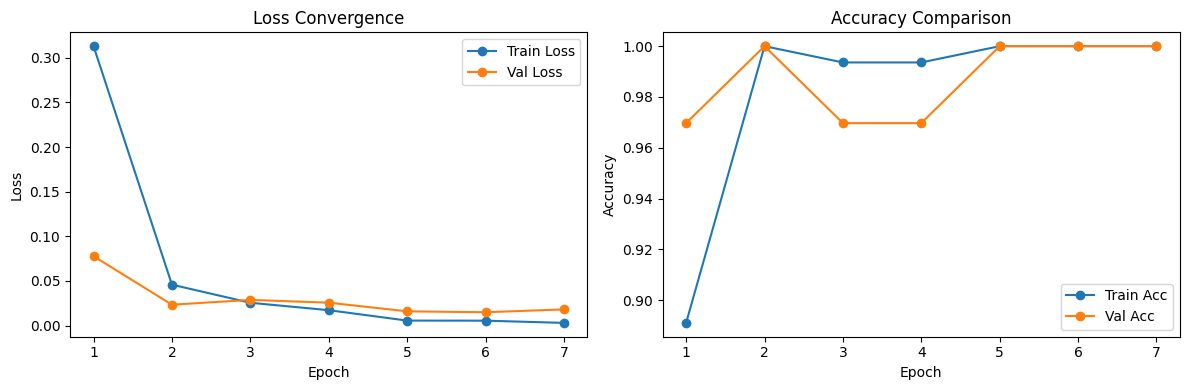

In [33]:
epochs = range(1, len(train_acc)+1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax[0].plot(epochs, train_loss, marker='o', label='Train Loss')
ax[0].plot(epochs, val_loss, marker='o', label='Val Loss')
ax[0].set_title("Loss Convergence")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy
ax[1].plot(epochs, train_acc, marker='o', label='Train Acc')
ax[1].plot(epochs, val_acc, marker='o', label='Val Acc')
ax[1].set_title("Accuracy Comparison")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

In [34]:
# evaluating model on test data
test_dir = f"{BASE_PATH}/Problem01_DuckChicken_Dataset/test"
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

evaluate_model(model, test_loader, device, class_names)


Classification Report:

              precision    recall  f1-score   support

     chicken       1.00      1.00      1.00        18
        duck       1.00      1.00      1.00        17

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



### Sample exmples for prediction

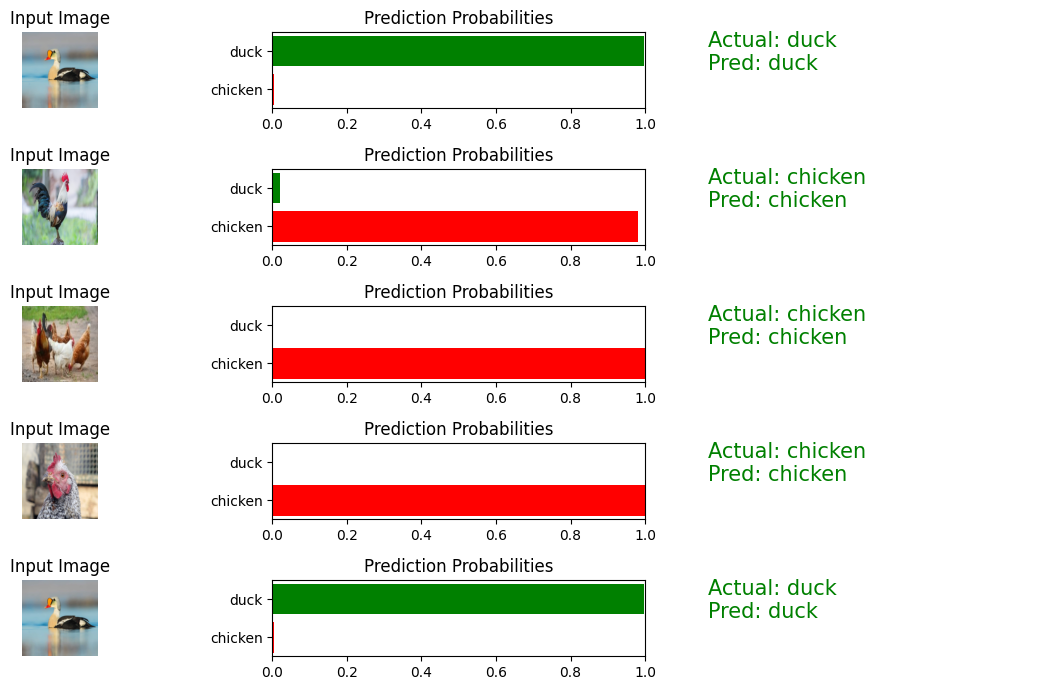

In [35]:
# get random 6 samples
indices = random.sample(range(len(test_dataset)), 5)

fig, ax = plt.subplots(5, 3, figsize=(12, 7))

model.eval()

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]

    input_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]

    pred_class = class_names[probs.argmax()]
    actual_class = class_names[label]

    # Column 1: Image
    img_np = img.permute(1, 2, 0).cpu().numpy()
    ax[i, 0].imshow(img_np)
    ax[i, 0].axis("off")
    ax[i, 0].set_title("Input Image")

    # Column 2: Horizontal Bar Plot
    colors = ['red' if cls == 'chicken' else 'green' for cls in class_names]

    ax[i, 1].barh(class_names, probs, color=colors)
    ax[i, 1].set_xlim(0, 1.0)
    ax[i, 1].set_title("Prediction Probabilities")

    # Column 3: Actual vs Predicted
    color = "green" if pred_class == actual_class else "red"
    ax[i, 2].text(0.1, 0.5,
                  f"Actual: {actual_class}\nPred: {pred_class}",
                  fontsize=15, color=color)
    ax[i, 2].axis("off")

plt.tight_layout()
plt.show()